## PPOL 5205 Data Science Final Project
## Katharyn Loweth
### Script 1: Initial Data Preprocessing

In [2]:
#loading packages
import pandas as pd
import numpy as np
from imdb import Cinemagoer
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer 
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer

In [98]:
#loading data
tmdb = pd.read_csv("TMDB_movie_dataset_v11.csv")
tmdb.head()
tmdb.columns
tmdb.shape

(1119536, 24)

In [103]:
#removing unecessary columns
tmdb_2 = tmdb.drop(["status", "adult", 'vote_count', "backdrop_path", 'original_title', 'homepage', 'poster_path', 'popularity'], axis = 1)
tmdb_2.head()


,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,2010-07-15,825532764,148,160000000,tt1375666,en,"Cobb, a skilled thief who commits corporate es...",Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,2014-11-05,701729206,169,165000000,tt0816692,en,The adventures of a group of explorers who mak...,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,2008-07-16,1004558444,152,185000000,tt0468569,en,Batman raises the stakes in his war on crime. ...,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,2009-12-15,2923706026,162,237000000,tt0499549,en,"In the 22nd century, a paraplegic Marine is di...",Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,2012-04-25,1518815515,143,220000000,tt0848228,en,When an unexpected enemy emerges and threatens...,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [104]:
#checking object types; transforming release date into time object
print(tmdb_2.dtypes)

tmdb_2['release_date'] = pd.to_datetime(tmdb_2['release_date'])
print(tmdb_2.release_date.dtype)
tmdb_2.head()

id                        int64
title                    object
vote_average            float64
release_date             object
revenue                   int64
runtime                   int64
budget                    int64
imdb_id                  object
original_language        object
overview                 object
tagline                  object
genres                   object
production_companies     object
production_countries     object
spoken_languages         object
keywords                 object
dtype: object
datetime64[ns]


,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,2010-07-15,825532764,148,160000000,tt1375666,en,"Cobb, a skilled thief who commits corporate es...",Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,2014-11-05,701729206,169,165000000,tt0816692,en,The adventures of a group of explorers who mak...,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,2008-07-16,1004558444,152,185000000,tt0468569,en,Batman raises the stakes in his war on crime. ...,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,2009-12-15,2923706026,162,237000000,tt0499549,en,"In the 22nd century, a paraplegic Marine is di...",Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,2012-04-25,1518815515,143,220000000,tt0848228,en,When an unexpected enemy emerges and threatens...,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [230]:
#filtering data to focus only on english language films that meet certain criteria
tmdb_filtered = tmdb_2[(tmdb_2['original_language'] == 'en')
                & (tmdb_2['release_date'] > '1974-01-01')
                & (tmdb_2['budget'] > 1000000)
                & (tmdb_2['imdb_id'].isna() == False)
                & (tmdb_2['tagline'].isna() == False)
                & (tmdb_2['revenue'] > 1000000)].reset_index(drop = True)

tmdb_filtered.shape #reduced dataset from over 1 million observations to ~4100



(5280, 16)

In [231]:
tmdb_filtered.budget.describe()

count    5.280000e+03
mean     3.931247e+07
std      4.509447e+07
min      1.065000e+06
25%      1.100000e+07
50%      2.500000e+07
75%      5.000000e+07
max      4.600000e+08
Name: budget, dtype: float64

In [232]:
tmdb_filtered.revenue.describe()

count    5.280000e+03
mean     1.129194e+08
std      1.985545e+08
min      1.007962e+06
25%      1.440025e+07
50%      4.339922e+07
75%      1.224313e+08
max      2.923706e+09
Name: revenue, dtype: float64

In [236]:
#reformmating the imdb_id to removing the leading characters so that the imdb id matches what is found on imdb scraper
tmdb_filtered['imdb_id_v2'] = tmdb_filtered['imdb_id'].str.lstrip('tt').str.lstrip('0')
#creating revenue_budget ratio variable 
tmdb_filtered['revenue_budget_ratio'] = round((tmdb_filtered['revenue'] / tmdb_filtered['budget']),3)

tmdb_filtered.sort_values(by = "revenue", ascending = False).reset_index(drop = True)

,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,tagline,genres,production_companies,production_countries,spoken_languages,keywords,imdb_id_v2,revenue_budget_ratio
0,19995,Avatar,7.573,2009-12-15,2923706026,162,237000000,tt0499549,en,"In the 22nd century, a paraplegic Marine is di...",Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",499549,12.336
1,299534,Avengers: Endgame,8.263,2019-04-24,2800000000,181,356000000,tt4154796,en,After the devastating events of Avengers: Infi...,Avenge the fallen.,"Adventure, Science Fiction, Action",Marvel Studios,United States of America,"English, Japanese, Xhosa","superhero, time travel, space travel, time mac...",4154796,7.865
2,76600,Avatar: The Way of Water,7.654,2022-12-14,2320250281,192,460000000,tt1630029,en,Set more than a decade after the events of the...,Return to Pandora.,"Science Fiction, Adventure, Action","20th Century Studios, Lightstorm Entertainment",United States of America,English,"dying and death, loss of loved one, alien life...",1630029,5.044
3,597,Titanic,7.900,1997-11-18,2264162353,194,200000000,tt0120338,en,101-year-old Rose DeWitt Bukater tells the sto...,Nothing on Earth could come between them.,"Drama, Romance","Paramount, 20th Century Fox, Lightstorm Entert...",United States of America,"English, French, German, Swedish, Italian, Rus...","epic, ship, drowning, panic, shipwreck, evacua...",120338,11.321
4,140607,Star Wars: The Force Awakens,7.293,2015-12-15,2068223624,136,245000000,tt2488496,en,Thirty years after defeating the Galactic Empi...,Every generation has a story.,"Adventure, Action, Science Fiction","Lucasfilm Ltd., Bad Robot",United States of America,English,"android, spacecraft, space opera",2488496,8.442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5275,286521,5 Flights Up,5.973,2014-09-05,1020921,92,6000000,tt2933544,en,A long-time married couple who've spent their ...,A coming of age story,Drama,"Revelations Entertainment, Lascaux Films, Lati...",United States of America,English,"new york city, married couple, moving out",2933544,0.170
5276,18476,Horsemen,5.877,2009-02-06,1017401,90,20000000,tt0892767,en,A recently widowed detective still grieving ov...,Four victims. Four painful secrets.,"Crime, Drama, Horror, Mystery, Thriller","Mandate Pictures, Platinum Dunes, Radar Pictures","Canada, United States of America",English,"hotel, police, detective, autopsy, murder, ser...",892767,0.051
5277,574060,Gunpowder Milkshake,6.375,2021-07-14,1015760,114,30000000,tt8368408,en,"To protect an 8-year-old girl, a dangerous ass...",Revenge is best served ice cold.,"Action, Crime, Thriller","Studio Babelsberg, Canal+, Ciné+, The Picture ...","France, Germany, United States of America","English, Russian","assassin, hitwoman, mother daughter estrangement",8368408,0.034
5278,440762,Jay and Silent Bob Reboot,5.673,2019-10-15,1011305,105,10000000,tt6521876,en,Jay and Silent Bob embark on a cross-country m...,Weed love to tell you a story...,Comedy,"SModcast Pictures, View Askew Productions, Mir...",United States of America,English,"comic book, hollywood, stoner, buddy comedy",6521876,0.101


In [237]:
tmdb_filtered.revenue_budget_ratio.describe()

count    5280.000000
mean        3.410670
std         5.561901
min         0.017000
25%         0.863750
50%         2.013000
75%         3.880250
max        94.077000
Name: revenue_budget_ratio, dtype: float64

In [238]:
tmdb_filtered.sort_values(by = "revenue_budget_ratio", ascending = False).reset_index(drop = True)

,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,tagline,genres,production_companies,production_countries,spoken_languages,keywords,imdb_id_v2,revenue_budget_ratio
0,36685,The Rocky Horror Picture Show,7.477,1975-08-14,112892319,100,1200000,tt0073629,en,"Sweethearts Brad and Janet, stuck with a flat ...",A different set of jaws.,"Comedy, Science Fiction, Fantasy, Horror","Michael White Productions, 20th Century Fox","United Kingdom, United States of America",English,"sexual identity, rock 'n' roll, transvestism, ...",73629,94.077
1,176,Saw,7.400,2004-10-01,103911669,103,1200000,tt0387564,en,Obsessed with teaching his victims the value o...,Live or die. Make your choice.,"Horror, Mystery, Crime","Twisted Pictures, Evolution Entertainment, Saw...",United States of America,English,"sadism, shotgun, detective, flashback, hospita...",387564,86.593
2,601,E.T. the Extra-Terrestrial,7.512,1982-06-11,792965500,115,10500000,tt0083866,en,An alien is left behind on Earth and saved by ...,He is afraid. He is alone. He is three million...,"Science Fiction, Adventure, Family, Fantasy","Universal Pictures, Amblin Entertainment",United States of America,English,"farewell, space marine, operation, flying sauc...",83866,75.521
3,8346,My Big Fat Greek Wedding,6.500,2002-04-19,368744044,95,5000000,tt0259446,en,A young Greek woman falls in love with a non-G...,Love is here to stay... so is her family.,"Comedy, Drama, Romance","Gold Circle Films, HBO, MPH Entertainment Prod...","Canada, United States of America","Greek, English","parent child relationship, culture clash, midl...",259446,73.749
4,9427,The Full Monty,6.990,1997-08-13,257850122,91,3500000,tt0119164,en,"Sheffield, England. Gaz, a jobless steelworker...",The year's most revealing comedy.,Comedy,"Redwave Films, Channel Four Films",United Kingdom,English,"northern england, police, suicide attempt, job...",119164,73.671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5275,51515,At Play in the Fields of the Lord,6.400,1991-12-06,1345903,189,36000000,tt0101373,en,Martin and Hazel Quarrier are small-town funda...,An adventure beyond the limits of civilization...,"Drama, Romance","Universal Pictures, The Saul Zaentz Company","Brazil, United States of America",English,"based on novel or book, missionary, civilizati...",101373,0.037
5276,37606,Valmont,6.695,1989-11-17,1132112,137,33000000,tt0098575,en,"Set in Baroque France, a scheming widow and he...",As unpredictable as love itself.,"Drama, Romance","Timothy Burrill Productions, Renn Productions,...","France, United States of America",English,"paris, france, based on novel or book, 18th ce...",98575,0.034
5277,574060,Gunpowder Milkshake,6.375,2021-07-14,1015760,114,30000000,tt8368408,en,"To protect an 8-year-old girl, a dangerous ass...",Revenge is best served ice cold.,"Action, Crime, Thriller","Studio Babelsberg, Canal+, Ciné+, The Picture ...","France, Germany, United States of America","English, Russian","assassin, hitwoman, mother daughter estrangement",8368408,0.034
5278,474227,Inhumans: The First Chapter,5.297,2017-09-01,2600000,88,80000000,tt21617448,en,An isolated community of superhumans fight to ...,The most uncanny heroes of all.,"Science Fiction, Action, Adventure","ABC Studios, IMAX, Marvel Television",United States of America,English,"superhero, royal family, based on comic, marve...",21617448,0.032


In [239]:
tmdb_filtered.tagline[0:50]

0                  Your mind is the scene of the crime.
1     Mankind was born on Earth. It was never meant ...
2                     Welcome to a world without rules.
3                           Enter the world of Pandora.
4                               Some assembly required.
5              Witness the beginning of a happy ending.
6                 An entire universe. Once and for all.
7                               Mischief. Mayhem. Soap.
8                           All heroes start somewhere.
9     Just because you are a character doesn't mean ...
10    The world will never be the same once you've s...
11                                 Let the magic begin.
12                   Heroes aren't born. They're built.
13          Life, liberty and the pursuit of vengeance.
14    Fear can hold you prisoner. Hope can set you f...
15                                   Avenge the fallen.
16                           Welcome to the Real World.
17            Nothing on Earth could come betwee

## Pulling information from IMDB web server

This uses the cinemagoer python package to connect to the imdb web server to collect and record specific information for each movie based on the imdb id. 

In [115]:
#initializing cinemagoer object from cinemagoer python package
ia = Cinemagoer()


In [246]:
def imdb_plot_and_syn(row):
    """
    Input: 
    row in dataframe

    Ouput: 
    row with 2 additional columns - imdb_plot and imdb_synopsis -- that contains information pulled from IMDB
    
    Using the IMDB Id in each row, using the Cinemagoer object to connect to the IMDb web server 
    to pull text information on the particular movie. Pulling both the plot (short description, a few sentences)
    and the plot synopsis (longer, more detailed version of plot). 

    Plot outline contains the most succinct text description of movie; plot contains multiple descriptions of film; default plot is then
    plot outline but in instances when that is not available pulling in the plot information from the first entry in the plot field. If both
    are not available, then returns NA as value. 

    
    """
    movieid = row['imdb_id_v2']
    imdb_movie = ia.get_movie(movieid)

    # get the plot
    # first look for plot outline; if not found, default to first entry in plot,  if not found list as "NA"
    movieplot = imdb_movie.get('plot outline')
    if not movieplot:  
        plot_list = imdb_movie.get('plot', [])  # Get 'plot', which is typically a list of multiple strings, default to empty list
        if plot_list:  # If 'plot' exists and has at least one item, pull and store the first item in the list 
            movieplot = plot_list[0]
        else:
            movieplot = "NA" 

    # Get the synopsis; if not found list as "NA"
    moviesyn = imdb_movie.get('synopsis')
    if not moviesyn:
        moviesyn = 'NA' 

    # Return results 
    return pd.Series([movieplot, moviesyn], index=['imdb_plot', 'imdb_synopsis'])

In [242]:
#creating small subsample to test how function workds
tmdb_test = tmdb_filtered[0:20]
tmdb_test.shape

#applying function to each row in subsample
tmdb_test[['imdb_plot', 'imdb_synopsis']] = tmdb_test.apply(imdb_plot_and_syn, axis=1)
tmdb_test.head()

/var/folders/zd/g468sr211nz26mz91q_cxlkr0000gn/T/ipykernel_91644/4103732468.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmdb_test[['imdb_plot', 'imdb_synopsis']] = tmdb_test.apply(imdb_plot_and_syn, axis=1)
/var/folders/zd/g468sr211nz26mz91q_cxlkr0000gn/T/ipykernel_91644/4103732468.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmdb_test[['imdb_plot', 'imdb_synopsis']] = tmdb_test.apply(imdb_plot_and_syn, axis=1)


,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,tagline,genres,production_companies,production_countries,spoken_languages,keywords,imdb_id_v2,revenue_budget_ratio,imdb_plot,imdb_synopsis
0,27205,Inception,8.364,2010-07-15,825532764,148,160000000,tt1375666,en,"Cobb, a skilled thief who commits corporate es...",Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",1375666,5.160,"Dom Cobb is a skilled thief, the absolute best...","Dominick ""Dom"" Cobb (Leonardo DiCaprio) and bu..."
1,157336,Interstellar,8.417,2014-11-05,701729206,169,165000000,tt0816692,en,The adventures of a group of explorers who mak...,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",816692,4.253,In the near future around the American Midwest...,"In the future, crop blight has caused civiliza..."
2,155,The Dark Knight,8.512,2008-07-16,1004558444,152,185000000,tt0468569,en,Batman raises the stakes in his war on crime. ...,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",468569,5.430,Set within a year after the events of Batman B...,The movie begins with a gang of men with clown...
3,19995,Avatar,7.573,2009-12-15,2923706026,162,237000000,tt0499549,en,"In the 22nd century, a paraplegic Marine is di...",Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",499549,12.336,"When his brother is killed in a robbery, parap...","In 2154, humans have depleted Earth's natural ..."
4,24428,The Avengers,7.710,2012-04-25,1518815515,143,220000000,tt0848228,en,When an unexpected enemy emerges and threatens...,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",848228,6.904,"Loki, the adopted brother of Thor, teams-up wi...",The Asgardian Loki (Tom Hiddleston) encounters...


In [243]:
tmdb_test.imdb_plot[1]

"In the near future around the American Midwest, Cooper, an ex-science engineer and pilot, is tied to his farming land with his daughter Murph and son Tom. As devastating sandstorms ravage Earth's crops, the people of Earth realize their life here is coming to an end as food begins to run out. Eventually stumbling upon a N.A.S.A. base 6 hours from Cooper's home, he is asked to go on a daring mission with a few other scientists into a wormhole because of Cooper's scientific intellect and ability to pilot aircraft unlike the other crew members. In order to find a new home while Earth decays, Cooper must decide to either stay, or risk never seeing his children again in order to save the human race by finding another habitable planet."

In [244]:
tmdb_test.imdb_synopsis[1]

'In the future, crop blight has caused civilization to regress into a failing agrarian society. Former NASA pilot Cooper (Matthew McConaughey) runs a farm with his family. Humanity needs more farmers to feed the world & the current scientific thinking believes that NASA Apollo missions were faked to bankrupt the Soviets (a belief that pisses Cooper off like nothing else). Murphy (Mackenzie Foy), Cooper\'s 10-year-old daughter, believes her room is haunted by a ghost trying to communicate with her. They discover the "ghost" is an unknown intelligence sending coded messages using gravitational waves, leaving binary coordinates in the dust that direct them to a secret NASA installation led by Professor John Brand (Michael Caine). Dr Brand tells Cooper that every year one crop dies & gets eliminated from the planet forever due to change in climatic conditions & severity of the dust storms. Soon, no crop will ever grow on Earth & the species will starve to death.Brand reveals that a wormhol

In [357]:
#commenting code out so it doesn't accidentially run -- it takes a few hours to complete; splitting file into two 

#tmdb_filtered[["imdb_plot", 'imdb_synopsis']] = tmdb_filtered.apply(imdb_plot_and_syn, axis=1)
#running whole dataset was causing timeout issues; splitting dataset into two and will merge again after collecting plot and synopsis
#tmdb_filtered_1 = tmdb_filtered[0:2601] #splitting data in half
#tmdb_filtered_2 = tmdb_filtered[2601:]

#tmdb_filtered_1[["imdb_plot", 'imdb_synopsis']] = tmdb_filtered_1.apply(imdb_plot_and_syn, axis=1)
#tmdb_filtered_1.head()

/var/folders/zd/g468sr211nz26mz91q_cxlkr0000gn/T/ipykernel_91644/2682938081.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmdb_filtered_1[["imdb_plot", 'imdb_synopsis']] = tmdb_filtered_1.apply(imdb_plot_and_syn, axis=1)
/var/folders/zd/g468sr211nz26mz91q_cxlkr0000gn/T/ipykernel_91644/2682938081.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmdb_filtered_1[["imdb_plot", 'imdb_synopsis']] = tmdb_filtered_1.apply(imdb_plot_and_syn, axis=1)


,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,tagline,genres,production_companies,production_countries,spoken_languages,keywords,imdb_id_v2,revenue_budget_ratio,imdb_plot,imdb_synopsis
0,27205,Inception,8.364,2010-07-15,825532764,148,160000000,tt1375666,en,"Cobb, a skilled thief who commits corporate es...",Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",1375666,5.160,"Dom Cobb is a skilled thief, the absolute best...","[Dominick ""Dom"" Cobb (Leonardo DiCaprio) and b..."
1,157336,Interstellar,8.417,2014-11-05,701729206,169,165000000,tt0816692,en,The adventures of a group of explorers who mak...,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",816692,4.253,In the near future around the American Midwest...,"[In the future, crop blight has caused civiliz..."
2,155,The Dark Knight,8.512,2008-07-16,1004558444,152,185000000,tt0468569,en,Batman raises the stakes in his war on crime. ...,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",468569,5.430,Set within a year after the events of Batman B...,[The movie begins with a gang of men with clow...
3,19995,Avatar,7.573,2009-12-15,2923706026,162,237000000,tt0499549,en,"In the 22nd century, a paraplegic Marine is di...",Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",499549,12.336,"When his brother is killed in a robbery, parap...","[In 2154, humans have depleted Earth's natural..."
4,24428,The Avengers,7.710,2012-04-25,1518815515,143,220000000,tt0848228,en,When an unexpected enemy emerges and threatens...,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",848228,6.904,"Loki, the adopted brother of Thor, teams-up wi...",[The Asgardian Loki (Tom Hiddleston) encounter...


In [378]:
#tmdb_filtered_2[["imdb_plot", 'imdb_synopsis']] = tmdb_filtered_2.apply(imdb_plot_and_syn, axis=1)
#tmdb_filtered_2.head()

/var/folders/zd/g468sr211nz26mz91q_cxlkr0000gn/T/ipykernel_91644/1594822216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmdb_filtered_2[["imdb_plot", 'imdb_synopsis']] = tmdb_filtered_2.apply(imdb_plot_and_syn, axis=1)
/var/folders/zd/g468sr211nz26mz91q_cxlkr0000gn/T/ipykernel_91644/1594822216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmdb_filtered_2[["imdb_plot", 'imdb_synopsis']] = tmdb_filtered_2.apply(imdb_plot_and_syn, axis=1)


,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,tagline,genres,production_companies,production_countries,spoken_languages,keywords,imdb_id_v2,revenue_budget_ratio,imdb_plot,imdb_synopsis
2601,11470,Jason X,4.834,2001-11-09,16951798,91,11000000,tt0211443,en,"In the year 2455, Old Earth is now a contamina...",Evil gets an upgrade.,"Horror, Science Fiction","Crystal Lake Entertainment, Sean S. Cunningham...",United States of America,English,"future, space marine, new jersey, sadism, psyc...",211443,1.541,"In the Year 2008, Jason Vorhees is cryogenical...","[In 2008, Jason Voorhees is captured by the U...."
2602,11873,The Color of Money,6.840,1986-10-17,52293982,119,13800000,tt0090863,en,"Former pool hustler ""Fast Eddie"" Felson decide...",The Hustler isn't what he used to be. But he h...,Drama,"Touchstone Pictures, Silver Screen Partners II",United States of America,"English, Spanish","sports, pool billiards, hustler, talent",90863,3.789,Pool hustler Fast Eddie Felson finds the young...,"[The Hustler is back, or is he?Setting his eye..."
2603,9708,The Wicker Man,4.300,2006-08-31,38805380,102,40000000,tt0450345,en,A sheriff investigating the disappearance of a...,Some sacrifices must be made,"Horror, Mystery, Thriller","Alcon Entertainment, Saturn Films, EFO Films, ...","Canada, Germany, Mexico, United Kingdom, Unite...",English,"island, california, airplane, based on novel o...",450345,0.970,A sheriff investigating the disappearance of a...,"[Edward Malus (Nicolas Cage), a Seattle police..."
2604,10215,Sliding Doors,6.566,1998-04-23,58809149,99,6000000,tt0120148,en,"London publicist Helen, effortlessly slides be...",What if one split second sent your life in two...,"Comedy, Drama, Fantasy, Romance","Paramount, Intermedia Films, Mirage Enterprise...","United Kingdom, United States of America",English,"double life, chance, commercial, time travel, ...",120148,9.802,"In London, the public relation Helen is fired ...",[Helen Quilley (Gwyneth Paltrow) gets fired fr...
2605,353069,Mother's Day,5.988,2016-04-28,48782670,118,25000000,tt4824302,en,Intersecting stories with different moms colli...,Celebrate the one day that connects us all,"Comedy, Drama, Romance","Rice Films, GulfStream Pictures, May Day Movie...",United States of America,English,"holiday, female friendship, remarriage, interr...",4824302,1.951,Follows the lives of different mothers on Moth...,NA


In [379]:
#adding files together again
#tmdb_filtered_all = pd.concat([tmdb_filtered_1, tmdb_filtered_2], axis=0)
#tmdb_filtered_all.shape

(5280, 20)

In [272]:
tmdb_filtered_all.head()

,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,tagline,genres,production_companies,production_countries,spoken_languages,keywords,imdb_id_v2,revenue_budget_ratio,imdb_plot,imdb_synopsis
0,27205,Inception,8.364,2010-07-15,825532764,148,160000000,tt1375666,en,"Cobb, a skilled thief who commits corporate es...",Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",1375666,5.160,"Dom Cobb is a skilled thief, the absolute best...","[Dominick ""Dom"" Cobb (Leonardo DiCaprio) and b..."
1,157336,Interstellar,8.417,2014-11-05,701729206,169,165000000,tt0816692,en,The adventures of a group of explorers who mak...,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",816692,4.253,In the near future around the American Midwest...,"[In the future, crop blight has caused civiliz..."
2,155,The Dark Knight,8.512,2008-07-16,1004558444,152,185000000,tt0468569,en,Batman raises the stakes in his war on crime. ...,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",468569,5.430,Set within a year after the events of Batman B...,[The movie begins with a gang of men with clow...
3,19995,Avatar,7.573,2009-12-15,2923706026,162,237000000,tt0499549,en,"In the 22nd century, a paraplegic Marine is di...",Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",499549,12.336,"When his brother is killed in a robbery, parap...","[In 2154, humans have depleted Earth's natural..."
4,24428,The Avengers,7.710,2012-04-25,1518815515,143,220000000,tt0848228,en,When an unexpected enemy emerges and threatens...,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",848228,6.904,"Loki, the adopted brother of Thor, teams-up wi...",[The Asgardian Loki (Tom Hiddleston) encounter...


In [380]:
#creating a separate date variable for year
tmdb_filtered_all['release_year'] = pd.to_datetime(tmdb_filtered_all['release_date']).dt.year
tmdb_filtered_all[["release_date", "release_year"]].head()
tmdb_filtered_all['release_year'].dtype

dtype('int64')

In [381]:
#loading in oscar nominee data
oscars = pd.read_csv("the_oscar_award.csv")
print(oscars.shape)
oscars.head()
#removing duplicates so that each film/year only appears once in dataset
oscar_nominees = oscars.drop_duplicates(subset=['year_film', 'film'])
print(oscar_nominees.shape)
oscar_nominees.head()

(10889, 7)
(5245, 7)


,year_film,year_ceremony,ceremony,category,name,film,winner
0,1927,1928,1,ACTOR,Richard Barthelmess,The Noose,False
1,1927,1928,1,ACTOR,Emil Jannings,The Last Command,True
2,1927,1928,1,ACTRESS,Louise Dresser,A Ship Comes In,False
3,1927,1928,1,ACTRESS,Janet Gaynor,7th Heaven,True
4,1927,1928,1,ACTRESS,Gloria Swanson,Sadie Thompson,False


In [382]:
#merging oscar nominee dataset with the movie dataset; boolean variable based on presence in the oscar film dataset. 
oscar_unique_films = oscar_nominees[["year_film", "film"]]

merged_df = tmdb_filtered_all.merge(oscar_unique_films, left_on=['release_year','title'], right_on = ['year_film','film'], how='left', indicator=True)

tmdb_filtered_all['Oscar_nominee'] = merged_df['_merge'] == 'both'

tmdb_filtered_all.head()

,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,...,production_companies,production_countries,spoken_languages,keywords,imdb_id_v2,revenue_budget_ratio,imdb_plot,imdb_synopsis,release_year,Oscar_nominee
0,27205,Inception,8.364,2010-07-15,825532764,148,160000000,tt1375666,en,"Cobb, a skilled thief who commits corporate es...",...,"Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",1375666,5.160,"Dom Cobb is a skilled thief, the absolute best...","[Dominick ""Dom"" Cobb (Leonardo DiCaprio) and b...",2010,True
1,157336,Interstellar,8.417,2014-11-05,701729206,169,165000000,tt0816692,en,The adventures of a group of explorers who mak...,...,"Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",816692,4.253,In the near future around the American Midwest...,"[In the future, crop blight has caused civiliz...",2014,True
2,155,The Dark Knight,8.512,2008-07-16,1004558444,152,185000000,tt0468569,en,Batman raises the stakes in his war on crime. ...,...,"DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",468569,5.430,Set within a year after the events of Batman B...,[The movie begins with a gang of men with clow...,2008,True
3,19995,Avatar,7.573,2009-12-15,2923706026,162,237000000,tt0499549,en,"In the 22nd century, a paraplegic Marine is di...",...,"Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",499549,12.336,"When his brother is killed in a robbery, parap...","[In 2154, humans have depleted Earth's natural...",2009,True
4,24428,The Avengers,7.710,2012-04-25,1518815515,143,220000000,tt0848228,en,When an unexpected enemy emerges and threatens...,...,Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",848228,6.904,"Loki, the adopted brother of Thor, teams-up wi...",[The Asgardian Loki (Tom Hiddleston) encounter...,2012,False


In [364]:
tmdb_filtered_all.Oscar_nominee.value_counts()

False    4273
True     1007
Name: Oscar_nominee, dtype: int64

In [366]:
tmdb_filtered_all.revenue_budget_ratio.describe()

count    5280.000000
mean        3.410670
std         5.561901
min         0.017000
25%         0.863750
50%         2.013000
75%         3.880250
max        94.077000
Name: revenue_budget_ratio, dtype: float64

In [399]:
tmdb_filtered_all.vote_average.describe()

count    5280.000000
mean        6.412252
std         0.832044
min         0.000000
25%         5.917000
50%         6.434500
75%         6.957750
max        10.000000
Name: vote_average, dtype: float64

In [405]:
tmdb_filtered_all[tmdb_filtered_all.vote_average == 0] #5 observations that have no voting information; first two entries are tv shows
#other cases we have no reviews; will drop results as they are irrelevant for analysis.

,id,title,vote_average,release_date,revenue,runtime,budget,imdb_id,original_language,overview,...,production_companies,production_countries,spoken_languages,keywords,imdb_id_v2,revenue_budget_ratio,imdb_plot,imdb_synopsis,release_year,Oscar_nominee
5275,1369009,Vikings,0.0,2013-03-03,8320694,45,40000000,tt2306299,en,Vikings transports us to the brutal and myste...,...,History,United States of America,"English, Russian","viking, king, norse god",2306299,0.208,The adventures of a Ragnar Lothbrok: the great...,NA,2013,False
5276,1234462,Halo 4,0.0,2012-11-06,220000000,62,40000000,tt2006120,en,"After being awoken from cryogenic sleep, Maste...",...,343 Industries,United States of America,English,NaN,2006120,5.500,Halo 4 is the start of a new saga in the Maste...,[cortana dies],2012,False
5277,398385,Birds of Passage,0.0,2001-05-27,11000000,115,2500000,tt0194704,en,A quest for freedom in the South China Sea. V...,...,"RSVP Film Studios, Adventure Film Productions,...",NaN,NaN,"ship, baby, china, survival, storm, human rights",194704,4.400,"Victims of China's ""One-Child"" policy. A Quest...",NA,2001,False
5278,903093,BuzziN',0.0,2017-09-01,1747037,5,1747037,tt7650604,en,A Bee gets more than it Beeargained for.,...,NaN,United States of America,English,grizzly bear,7650604,1.000,A Bee gets more than it Beeargained for.,NA,2017,False
5279,619265,The Cabin House,0.0,2019-10-31,13000000,120,13000000,tt10555920,en,A group of college friends rent a cabin in a r...,...,"G.P.L.A., Los Angeles, Conner Mac Studios",NaN,English,NaN,10555920,1.000,Two years ago a couple college kids go missing...,NA,2019,False


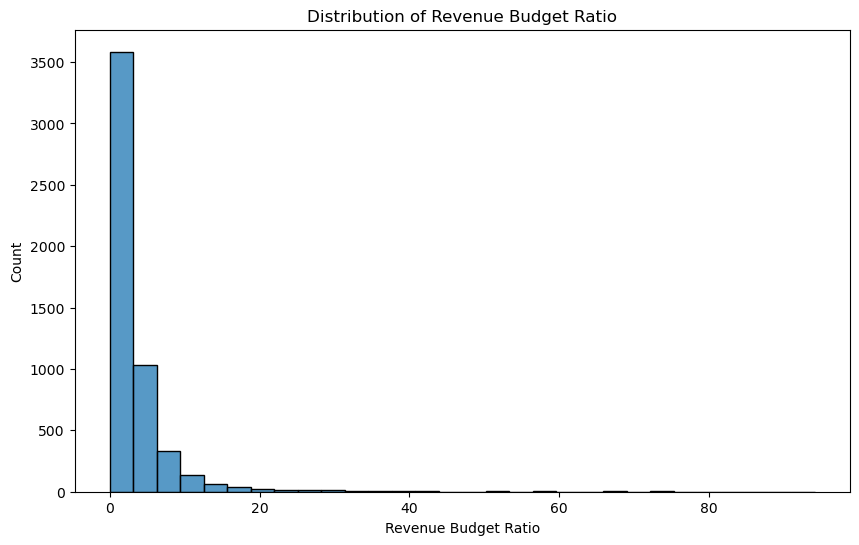

In [367]:
plt.figure(figsize=(10, 6))
sns.histplot(tmdb_filtered_all.revenue_budget_ratio, bins = 30)
plt.title("Distribution of Revenue Budget Ratio")
plt.xlabel("Revenue Budget Ratio")
plt.show()

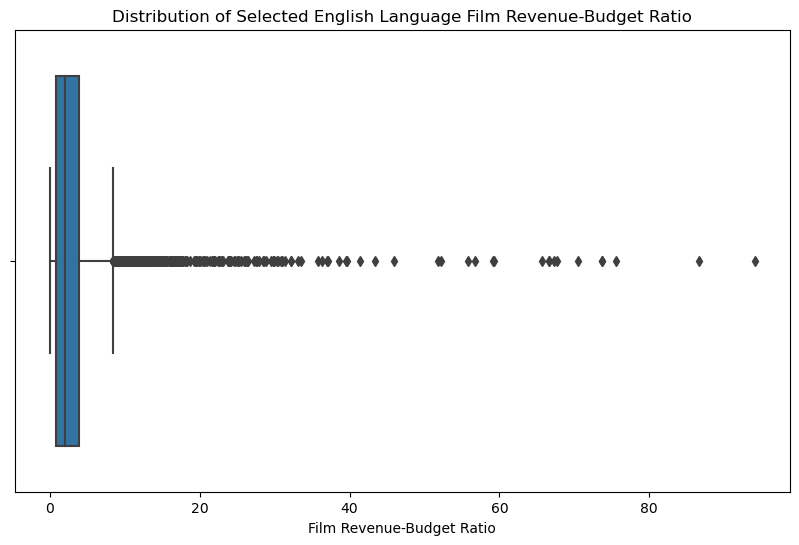

In [368]:
plt.figure(figsize=(10, 6))
sns.boxplot(x= tmdb_filtered_all.revenue_budget_ratio)
plt.title("Distribution of Selected English Language Film Revenue-Budget Ratio")
plt.xlabel("Film Revenue-Budget Ratio")
plt.show()

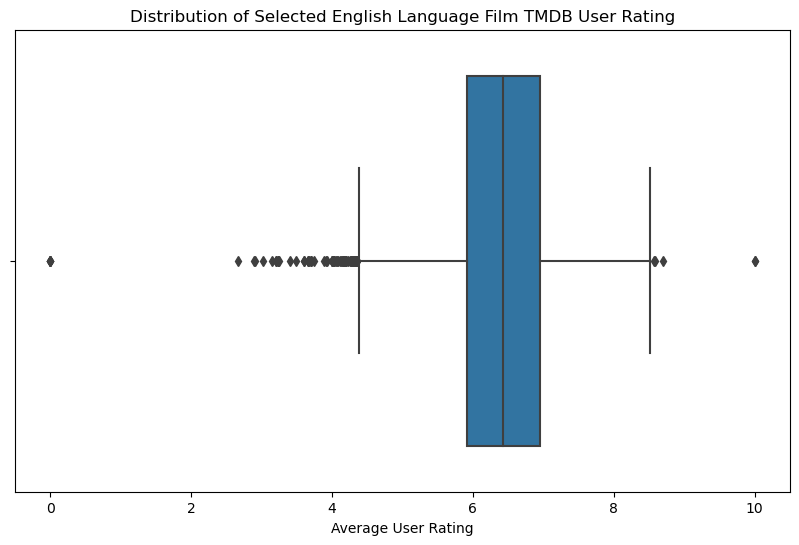

In [369]:
plt.figure(figsize=(10, 6))
sns.boxplot(x= tmdb_filtered_all.vote_average)
plt.title("Distribution of Selected English Language Film TMDB User Rating")
plt.xlabel("Average User Rating")
plt.show()

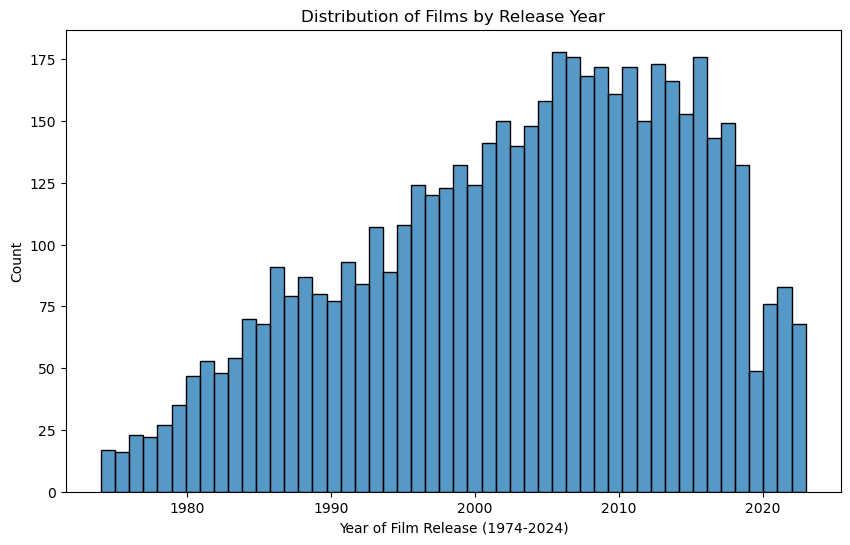

In [427]:
plt.figure(figsize=(10, 6))
sns.histplot(tmdb_filtered_all.release_year, bins = 50)
plt.title("Distribution of Films by Release Year")
plt.xlabel("Year of Film Release (1974-2024)")
plt.show()

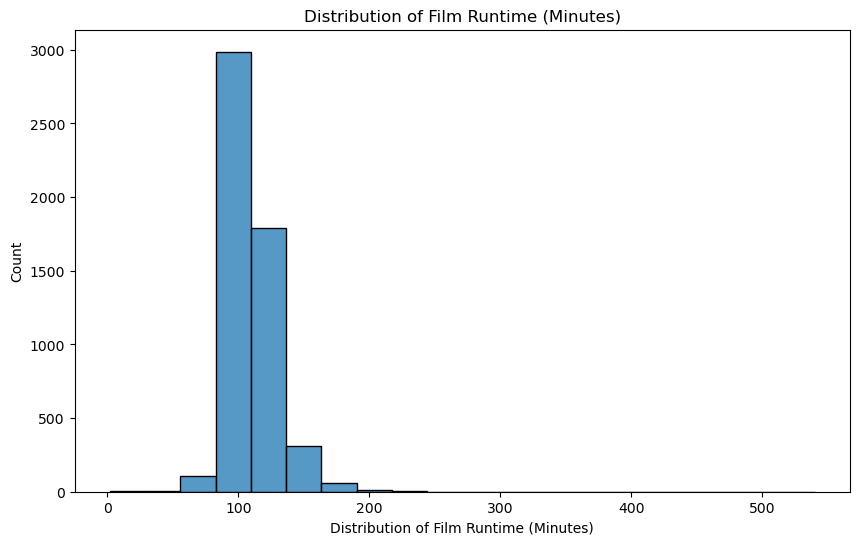

In [370]:
plt.figure(figsize=(10, 6))
sns.histplot(tmdb_filtered_all.runtime, bins = 20)
plt.title("Distribution of Film Runtime (Minutes)")
plt.xlabel("Distribution of Film Runtime (Minutes)")
plt.show()

In [406]:
tmdb_filtered_all_2 = tmdb_filtered_all[tmdb_filtered_all.vote_average != 0]
tmdb_filtered_all_2.shape

(5275, 22)

In [424]:
round(tmdb_filtered_all_2.vote_average.describe(),2)

count    5275.00
mean        6.42
std         0.81
min         2.66
25%         5.92
50%         6.44
75%         6.96
max        10.00
Name: vote_average, dtype: float64

In [426]:
tmdb_filtered_all_2.Oscar_nominee.value_counts()

False    4268
True     1007
Name: Oscar_nominee, dtype: int64

In [425]:
round(tmdb_filtered_all_2.revenue_budget_ratio.describe(),2)

count    5275.00
mean        3.41
std         5.56
min         0.02
25%         0.86
50%         2.01
75%         3.88
max        94.08
Name: revenue_budget_ratio, dtype: float64

In [407]:
#tmdb_filtered_all_2.to_csv("1974_2024_englishlanguagefilms.csv", index = False, header = True)

## Initial Text Exploration

In [4]:
tmdb_filtered_all_2 = pd.read_csv("1974_2024_englishlanguagefilms.csv")

In [5]:
stop_words= stopwords.words('english')
print(stop_words)

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [6]:
stop_words_2 = ['what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 
                'been', 'being', 'have', 'has', 'had', 'having', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 
                'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'between', 'into', 
                'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 
                'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 
                'other', 'some', 'such', 'only', 'so', 's', 't', 'can', 'just', 'don', 'should', "should've", 'd', 'll', 
                'm', 'o', 're', 've', 'y', 'll', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 
                'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', 
                "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 
                'won', 'wouldn', "wouldn't"]

#removing pronouns from stopword list because they may be important for messaging 
#removing no/not/nor, now, 'than', 'too', 'very', 'same', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'own', 'against', 'will', "won't", "don't", 'do'


#adding 'll'


In [8]:
vectorizer = CountVectorizer(stop_words = stop_words_2)
tagline_vector = vectorizer.fit_transform(tmdb_filtered_all_2.tagline)
print(tagline_vector.shape)

feature_matrix = tagline_vector.todense()
feature_names = vectorizer.get_feature_names_out()
df = pd.DataFrame(feature_matrix, columns=feature_names)
df.head()

(5275, 4610)


,00,000,007,05,06,08,10,100,1000,1001,...,yule,zebra,zero,zest,zeta,zhivago,zombies,zone,zones,zoo
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df_tagline = pd.DataFrame(tagline_vector.toarray(), 
                     columns=vectorizer.get_feature_names_out(), 
                     index=tmdb_filtered_all_2.id)

index = df_tagline.sum().sort_values(ascending=False).index
df_tagline[index].head()

,you,it,he,one,they,your,no,love,all,his,...,heels,height,heiress,heists,helen,helping,henk,hercule,heritage,keng
id,,,,,,,,,,,,,,,,,,,,,
27205,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
157336,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
155,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24428,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
df_tagline.sum().sort_values(ascending=False)[0:25]

you      850
it       611
he       439
one      428
they     367
your     310
no       280
love     268
all      244
his      239
life     208
never    207
story    205
world    203
will     196
man      196
not      175
get      164
she      160
time     160
back     143
every    134
their    132
new      132
do       130
dtype: int64

In [20]:
tmdb_filtered_all_2.imdb_plot.isna().value_counts()
tmdb_filtered_all_2.dropna(subset=['imdb_plot'], inplace=True)

In [21]:
vectorizer2 = CountVectorizer(stop_words = 'english')
plot_vector = vectorizer2.fit_transform(tmdb_filtered_all_2.imdb_plot)
print(plot_vector.shape)

feature_matrix_plot = plot_vector.todense()
feature_names_plot = vectorizer2.get_feature_names_out()
df= pd.DataFrame(feature_matrix_plot, columns=feature_names_plot)
df.head()

(5272, 29958)


,00,000,007,05,06,10,100,1000,1000th,100th,...,zus,zuzu,zygon,zym,ásgeirsson,æon,émigré,époque,état,über
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [416]:
df_plot = pd.DataFrame(plot_vector.toarray(), 
                     columns=vectorizer2.get_feature_names_out(), 
                     index=tmdb_filtered_all_2.id)

index = df_plot.sum().sort_values(ascending=False).index
df_plot[index].head()

,life,new,world,family,man,time,young,father,love,help,...,moritz,claremont,mornings,moronic,morons,morphine,morphology,morra,morrell,über
id,,,,,,,,,,,,,,,,,,,,,
27205,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
157336,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
155,0,2,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
19995,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
24428,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [417]:
df_plot.sum().sort_values(ascending=False)[0:30]

life       1633
new        1399
world       996
family      991
man         959
time        877
young       866
father      808
love        751
help        726
years       713
finds       701
old         691
way         675
friends     627
home        611
school      603
friend      572
wife        565
story       560
mother      557
year        544
city        543
son         541
town        529
soon        516
day         508
woman       502
make        501
lives       496
dtype: int64

In [22]:
#looping through count vectorizer with a varying minimum document frequency requirement
#fitting to abstracts in the sample and pulling the number of features (shape[1]) from the vectorized matrix
#saving that number in a list
feat = [CountVectorizer(min_df = i).fit_transform(tmdb_filtered_all_2.imdb_plot).shape[1] for i in range(1,26)]
print(feat)

[30253, 16610, 12268, 9858, 8351, 7249, 6479, 5837, 5313, 4884, 4521, 4211, 3945, 3702, 3507, 3307, 3128, 2969, 2823, 2695, 2593, 2477, 2389, 2292, 2215]


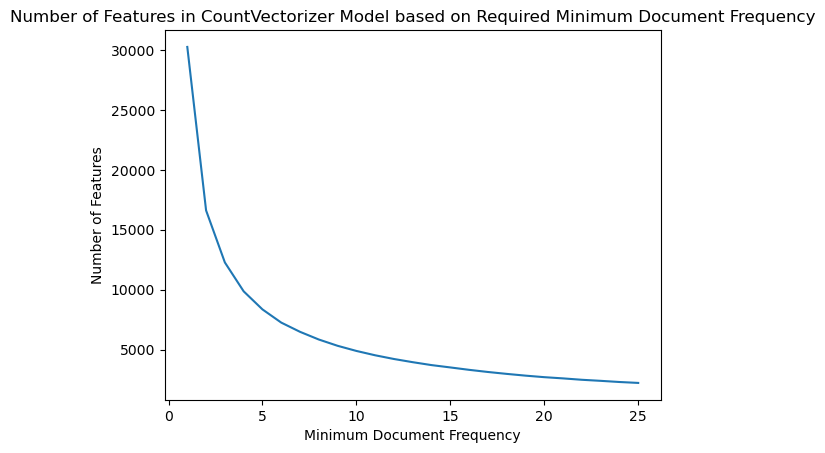

In [23]:
plt.plot(range(1,26), feat)
plt.xlabel('Minimum Document Frequency')
plt.ylabel('Number of Features')
plt.title('Number of Features in CountVectorizer Model based on Required Minimum Document Frequency')
plt.show() 

In [12]:
tags = tmdb_filtered_all_2[["id","title", "tagline"]].reset_index(drop = True)
tags["taglines_split"] = tags.tagline.str.split()
tags["taglines_word_count"] = [len(tags.taglines_split[i]) for i in range(len(tags))]
tags.head()

,id,title,tagline,taglines_split,taglines_word_count
0,27205,Inception,Your mind is the scene of the crime.,"[Your, mind, is, the, scene, of, the, crime.]",8
1,157336,Interstellar,Mankind was born on Earth. It was never meant ...,"[Mankind, was, born, on, Earth., It, was, neve...",12
2,155,The Dark Knight,Welcome to a world without rules.,"[Welcome, to, a, world, without, rules.]",6
3,19995,Avatar,Enter the world of Pandora.,"[Enter, the, world, of, Pandora.]",5
4,24428,The Avengers,Some assembly required.,"[Some, assembly, required.]",3


In [13]:
round(tags.taglines_word_count.describe(),3)

count    5275.000
mean        7.871
std         4.626
min         1.000
25%         5.000
50%         7.000
75%        10.000
max        42.000
Name: taglines_word_count, dtype: float64

In [14]:
print(tags.loc[tags['taglines_word_count'].idxmax()])

tags.loc[tags['taglines_word_count'].idxmin()]

id                                                                 29787
title                                                      Monkey Shines
tagline                Once there was a man whose prison was a chair....
taglines_split         [Once, there, was, a, man, whose, prison, was,...
taglines_word_count                                                   42
Name: 4405, dtype: object


id                                             283995
title                  Guardians of the Galaxy Vol. 2
tagline                                    Obviously.
taglines_split                           [Obviously.]
taglines_word_count                                 1
Name: 34, dtype: object

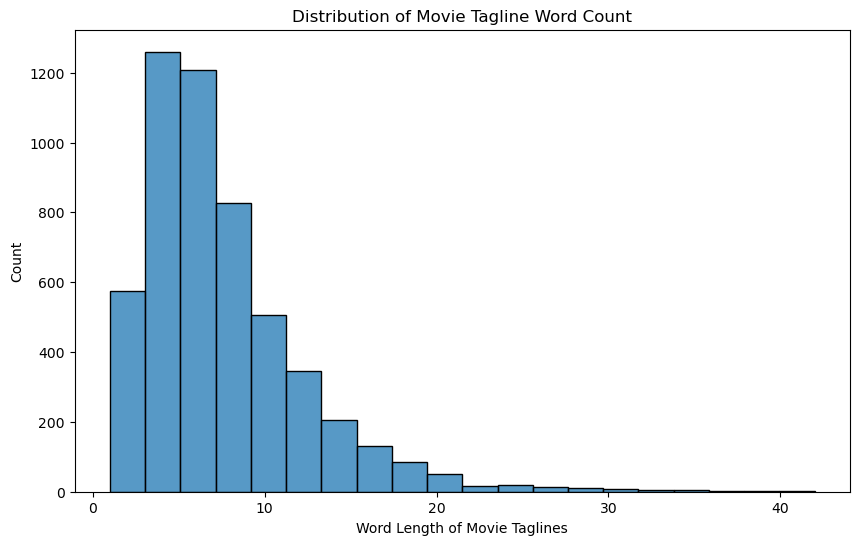

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(tags.taglines_word_count, bins = 20)
plt.title("Distribution of Movie Tagline Word Count")
plt.xlabel("Word Length of Movie Taglines")
plt.show()

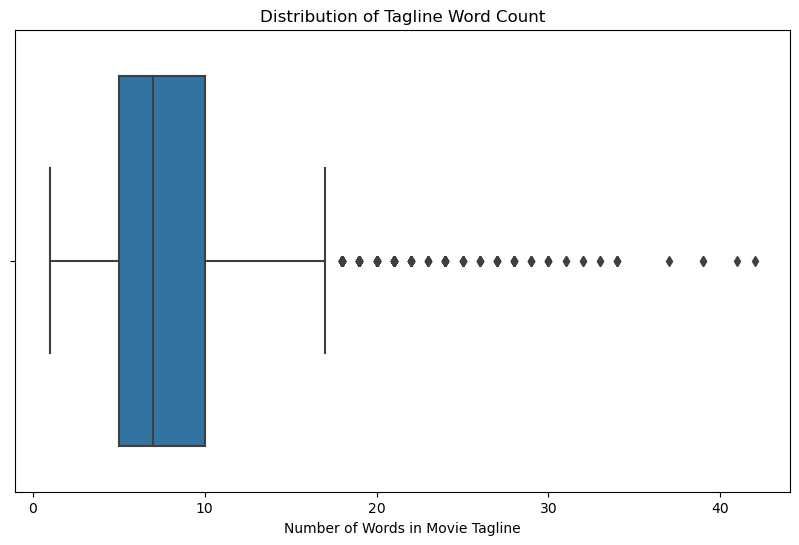

In [422]:
plt.figure(figsize=(10, 6))
sns.boxplot(x= tags.taglines_word_count)
plt.title("Distribution of Tagline Word Count")
plt.xlabel("Number of Words in Movie Tagline")
plt.show()

## Works Cited

https://cinemagoer.readthedocs.io/en/latest/

(2024, October 23). Full TMDB Movies Dataset 2024 (1M Movies). kaggle.com. https://www.kaggle.
com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/data

(n.d.). The Movie Database. TMDB. https://www.themoviedb.org/

(2024). The Oscar Award, 1927 - 2024. kaggle.com. https://www.kaggle.com/datasets/unanimad/the-
oscar-award
